## Imports

In [56]:
import dill 
import random
from math import sqrt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import shap

In [57]:
x_full = pd.read_csv("pipe/data/processed/x_full.csv")
x_full.head()

,lag_1_month,lag_2_month,lag_3_month,avg_item_cnt_prev_month,avg_shop_cnt_prev_month,month,year,item_age,shop_age,category_age,...,group_cnt_lag1,group_cnt_all_shops_lag1,item_name_first4,item_name_first6,item_name_first11,group_id,group_age,category_cnt_median_lag1,category_cnt_all_shops_median_lag1,city_cnt_lag1
0,1,4,0,3,1,4,2013,2,3,3,...,1,1,2,2,3,10,3,1,1,1
1,0,0,0,1,1,4,2013,3,3,3,...,2,1,34,39,55,11,3,1,1,1
2,1,1,1,1,1,4,2013,3,3,3,...,1,2,35,43,59,14,3,1,1,1
3,2,4,2,5,1,4,2013,3,3,3,...,1,2,35,43,59,14,3,1,1,1
4,0,0,0,2,3,4,2013,1,3,3,...,1,2,35,43,59,14,3,1,1,1


In [58]:
x = pd.read_csv("pipe/data/processed/x.csv")
x_full.head()

,lag_1_month,lag_2_month,lag_3_month,avg_item_cnt_prev_month,avg_shop_cnt_prev_month,month,year,item_age,shop_age,category_age,...,group_cnt_lag1,group_cnt_all_shops_lag1,item_name_first4,item_name_first6,item_name_first11,group_id,group_age,category_cnt_median_lag1,category_cnt_all_shops_median_lag1,city_cnt_lag1
0,1,4,0,3,1,4,2013,2,3,3,...,1,1,2,2,3,10,3,1,1,1
1,0,0,0,1,1,4,2013,3,3,3,...,2,1,34,39,55,11,3,1,1,1
2,1,1,1,1,1,4,2013,3,3,3,...,1,2,35,43,59,14,3,1,1,1
3,2,4,2,5,1,4,2013,3,3,3,...,1,2,35,43,59,14,3,1,1,1
4,0,0,0,2,3,4,2013,1,3,3,...,1,2,35,43,59,14,3,1,1,1


In [59]:
# Scale x
scaler = StandardScaler()
scaler.fit(x)
scaled_x = scaler.transform(x)
x = pd.DataFrame(scaled_x, columns=x.columns, index=x.index)

# Scale x_full
scaler = StandardScaler()
scaler.fit(x_full)
scaled_x = scaler.transform(x_full)
x_full = pd.DataFrame(scaled_x, columns=x_full.columns, index=x_full.index)

In [60]:
y = pd.read_csv("pipe/data/processed/y.csv").values.ravel()

## Descriptive statistics

In [62]:
def descr_features(df):
    data = df.copy()

    # Data types
    features = data.dtypes.to_frame(name="data_type")

    # Number and percent of missing data
    features["n_NaN"] = data.isna().sum()
    features["%NaN"] = round(features["n_NaN"] / len(data) * 100, 2)

    # Number of unique values
    features["nunique"] = data.nunique().values

    # describe() info
    describe_train = data.describe(include="all").round(1).T
    features = pd.merge(
        features,
        describe_train.round(0),
        how="left",
        left_index=True,
        right_index=True
    )

    return features

In [63]:
descr_features(x_full)

,data_type,n_NaN,%NaN,nunique,count,mean,std,min,25%,50%,75%,max
lag_1_month,float64,0,0.0,21,1363322.0,-0.0,1.0,-1.0,-0.0,-0.0,0.0,7.0
lag_2_month,float64,0,0.0,21,1363322.0,-0.0,1.0,-1.0,-1.0,-0.0,0.0,7.0
lag_3_month,float64,0,0.0,21,1363322.0,-0.0,1.0,-0.0,-0.0,-0.0,-0.0,7.0
avg_item_cnt_prev_month,float64,0,0.0,21,1363322.0,-0.0,1.0,-1.0,-0.0,-0.0,0.0,7.0
avg_shop_cnt_prev_month,float64,0,0.0,21,1363322.0,-0.0,1.0,-1.0,-0.0,-0.0,0.0,7.0
month,float64,0,0.0,12,1363322.0,-0.0,1.0,-2.0,-1.0,0.0,1.0,2.0
year,float64,0,0.0,3,1363322.0,-0.0,1.0,-1.0,-1.0,-0.0,1.0,1.0
item_age,float64,0,0.0,34,1363322.0,-0.0,1.0,-1.0,-1.0,-0.0,0.0,3.0
shop_age,float64,0,0.0,34,1363322.0,-0.0,1.0,-2.0,-1.0,-0.0,1.0,2.0
category_age,float64,0,0.0,34,1363322.0,0.0,1.0,-2.0,-1.0,-0.0,1.0,2.0


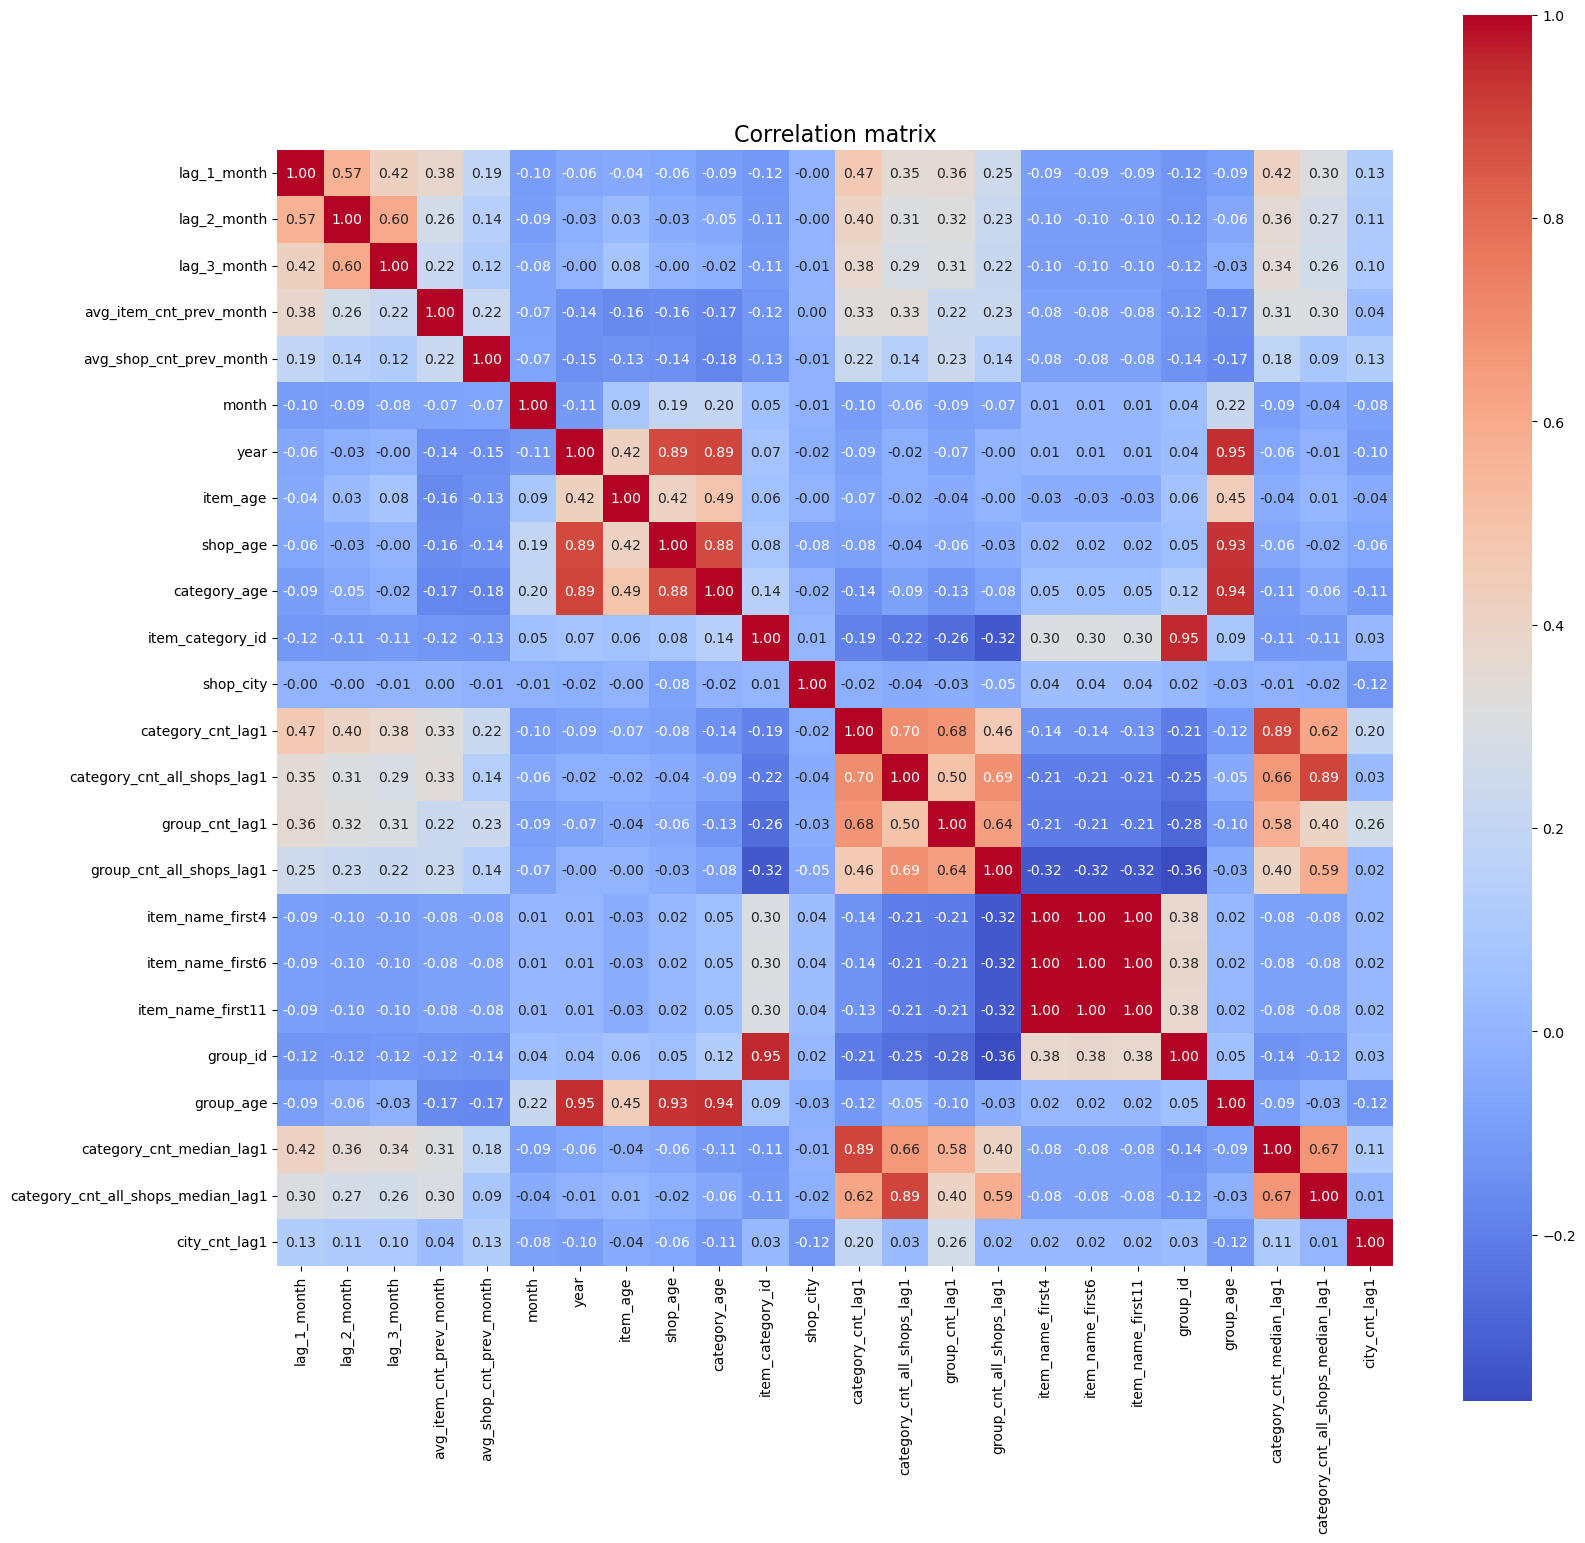

In [64]:
# Display the correlation matrix
plt.figure(figsize=(18, 18))
plt.title("Correlation matrix", fontsize=16)
corr_matrix = x_full.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True);

Some features like item_name_firstx are strongly correlated with each other. item_id and item_category_id also show high correlation. year and age are closely linked. Lag features by category, medium, and all shops are strongly related and may overlap.

## Feature importance

In [67]:
# Get best model
with open("pipe/models/model_wthout_feat_selection.pkl", "rb") as file:
    model = dill.load(file)

In [68]:
# Variance analysisof features
def analyze_feature_variance(x, threshold=0.01):

    variances = x.var(ddof=0)
    summary = pd.DataFrame({
        'feature': variances.index,
        'variance': variances.values,
        'low_variance': variances.values < threshold
    }).sort_values(by='variance')

    print(f"Total features: {len(x.columns)}")
    print(f"Low-variance features (< {threshold}): {summary['low_variance'].sum()}")
    print("Variance spread:")
    print(summary.describe())

    return summary
    
analyze_feature_variance(x_full)

Total features: 24
Low-variance features (< 0.01): 0
Variance spread:
           variance
count  2.400000e+01
mean   1.000000e+00
std    1.200110e-11
min    1.000000e+00
25%    1.000000e+00
50%    1.000000e+00
75%    1.000000e+00
max    1.000000e+00


,feature,variance,low_variance
0,lag_1_month,1.0,False
12,category_cnt_lag1,1.0,False
3,avg_item_cnt_prev_month,1.0,False
5,month,1.0,False
4,avg_shop_cnt_prev_month,1.0,False
21,category_cnt_median_lag1,1.0,False
19,group_id,1.0,False
6,year,1.0,False
15,group_cnt_all_shops_lag1,1.0,False
20,group_age,1.0,False


In [69]:
# Import base rfr model for feature selection
with open("pipe/models/rfr.pkl", "rb") as file:
    rf = dill.load(file)

In [70]:
x_full.shape

(1363322, 24)

In [71]:
importances = rf.feature_importances_
importance_df = pd.DataFrame({
            'feature': x_full.columns,
            'importance': importances
}).sort_values(by='importance', ascending=False)

selected_features_importance = importance_df[
            importance_df['importance'] >= 0.005]['feature'].tolist()

rejected = importance_df[
            importance_df['importance'] < 0.005]['feature'].tolist()

print(f"Importance-based selection: {len(selected_features_importance)} features out of {x_full.shape[1]}")
print(f"Selected features: {selected_features_importance}")
print(f"Rejected features: {rejected}")

Importance-based selection: 7 features out of 24
Selected features: ['avg_item_cnt_prev_month', 'lag_1_month', 'group_age', 'item_age', 'category_cnt_lag1', 'lag_3_month', 'group_cnt_lag1']
Rejected features: ['avg_shop_cnt_prev_month', 'item_category_id', 'category_cnt_median_lag1', 'lag_2_month', 'month', 'group_id', 'shop_city', 'category_cnt_all_shops_median_lag1', 'city_cnt_lag1', 'category_age', 'category_cnt_all_shops_lag1', 'shop_age', 'group_cnt_all_shops_lag1', 'item_name_first11', 'year', 'item_name_first6', 'item_name_first4']


C:\Users\USER\AppData\Local\Temp\ipykernel_10676\3564044419.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


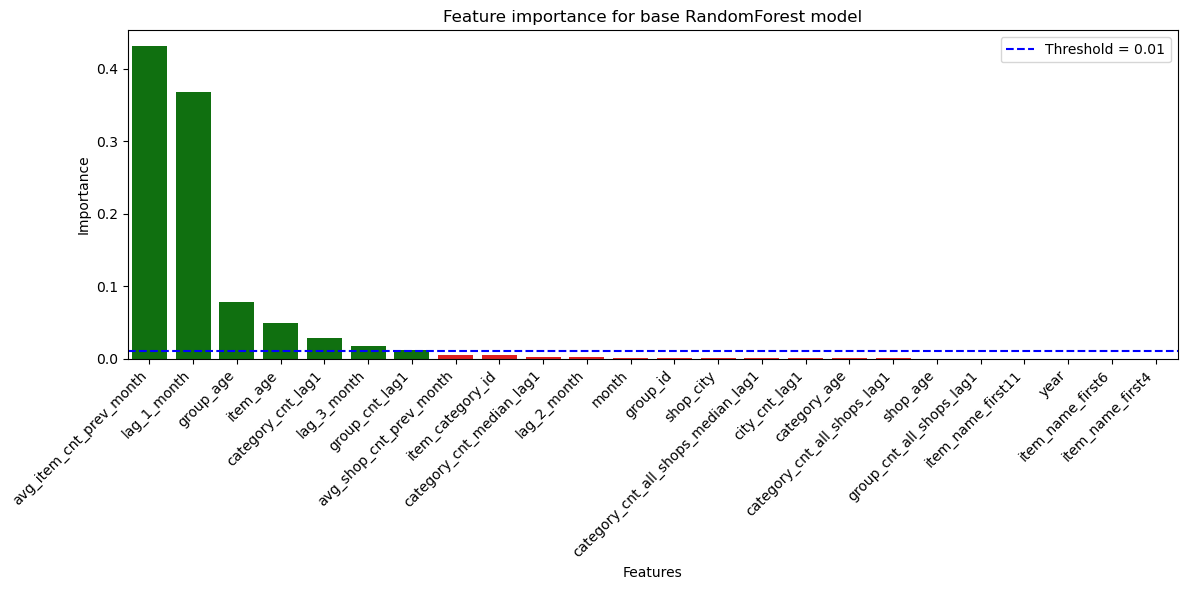

In [72]:
# Visualize feature importance for rfr model
plt.figure(figsize=(12, 6))
sns.barplot(
    data=importance_df,
    x='feature',
    y='importance',
    palette=['green' if f in selected_features_importance else 'red' for f in importance_df['feature']]
)
plt.axhline(0.01, color='blue', linestyle='--', label='Threshold = 0.01')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature importance for base RandomForest model')
plt.legend()
plt.tight_layout()
plt.show()

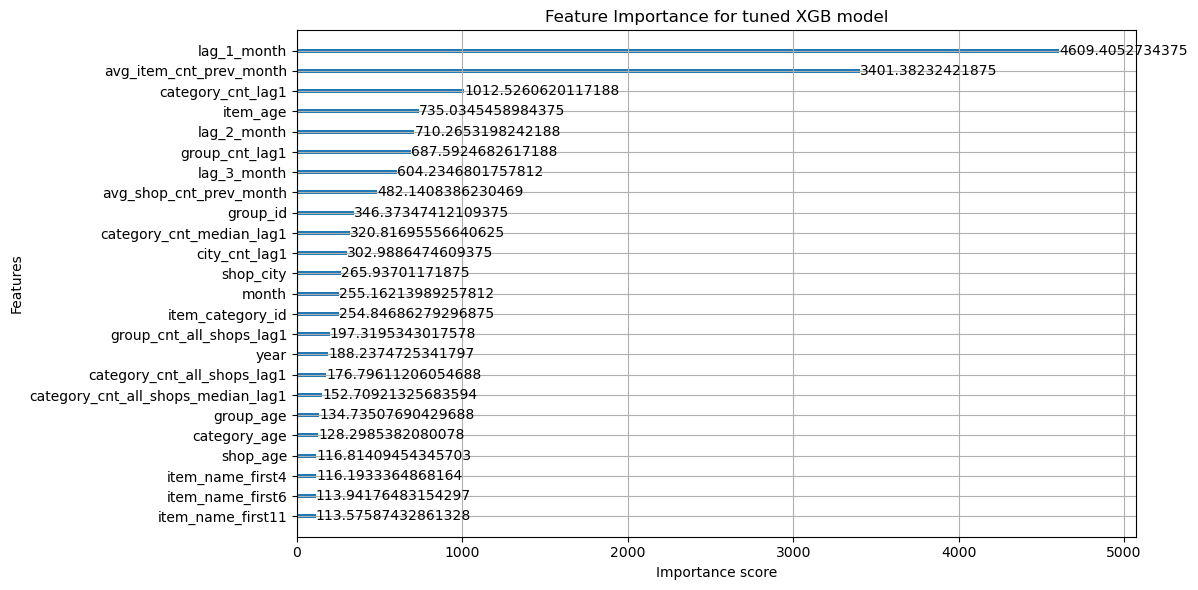

In [73]:
# Feature imortance for xgb
fig, ax = plt.subplots(figsize=(12, 6))
xgb.plot_importance(model, importance_type='gain', ax=ax)
plt.title("Feature Importance for tuned XGB model")
plt.tight_layout()
plt.show()

We need to exclude:
- item_name_fisrtx features wich are highly correlated and unimportant for tuned model.
- group_id, category_cnt_all_shops_lag1, category_cnt_median_lag1 which demonstrate lower importance and high correlation.
- one of the features group_age and category_age should be remained because of high correlation

## SHAP interpretation

In [126]:
# Get best model
with open("pipe/models/sales_model.pkl", "rb") as file:
    model = dill.load(file)["model"]

In [130]:
# Sample 10 000 rows from the full dataset for SHAP analysis
x_sample = x.sample(10000).reset_index(drop=True)

# # Compute SHAP values for the sampled data
# explainer = shap.TreeExplainer(model, approximate=True)
# shap_values = explainer(x_sample)

with open("shap_values.pkl", "rb") as file:
    shap_values = dill.load(file)

In [131]:
# with open("shap_values.pkl", "wb") as file:
#     dill.dump(shap_values,file)

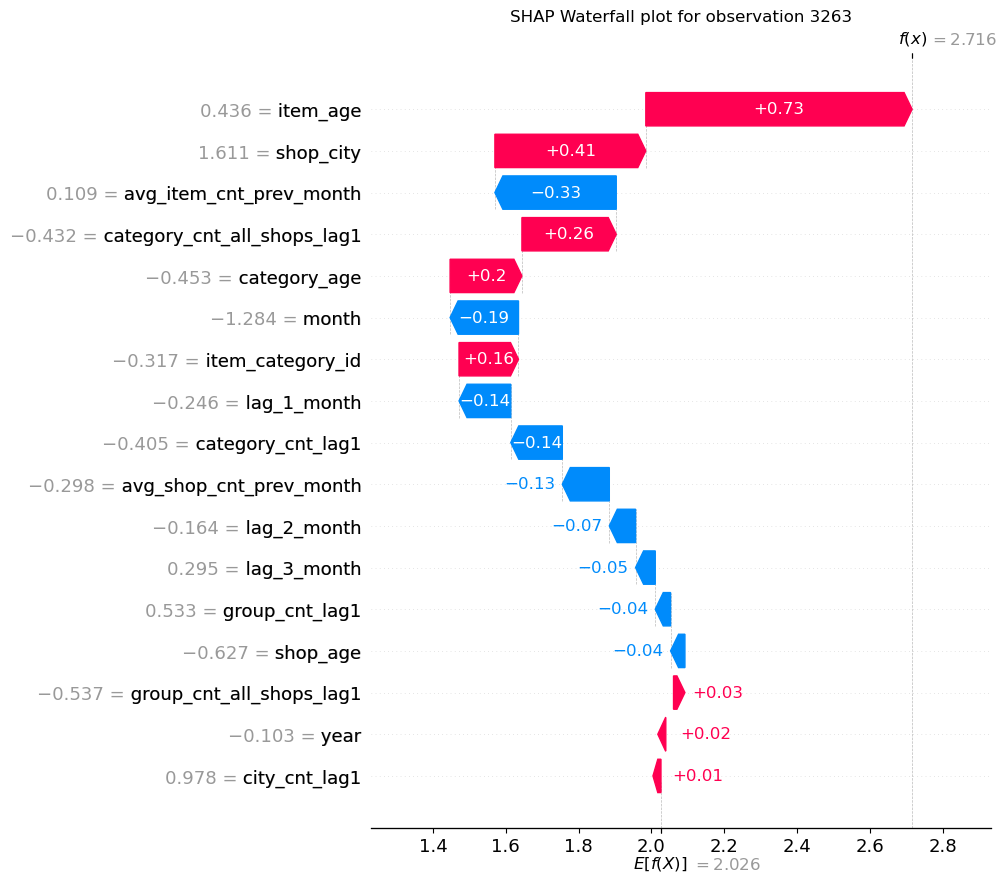

In [132]:
# Get an individual observation
instance_index = random.randint(0, len(x_sample) - 1)
# Visualize its importance

plt.title("SHAP Waterfall plot for observation {}".format(instance_index))
shap.plots.waterfall(shap_values[instance_index], max_display=25)

In [133]:
# Force plot for an observation
x_instance = x.iloc[[instance_index]]
shap.initjs()
print("Force plot of prediction for one observation")
shap.force_plot(explainer.expected_value, shap_values[instance_index].values, x_instance)

Force plot of prediction for one observation


The most impactful positive features include `category_cnt_all_shops_log1`, `item_age`, and `shop_city`. In contrast, raw features like `avg_item_cnt_prev_month` and `month` had strong negative SHAP values. 

Features `city_cnt_lag1`, `year`, `group_cnt_all_shops_lag1` were unimportant in prediction of the value for individual observation

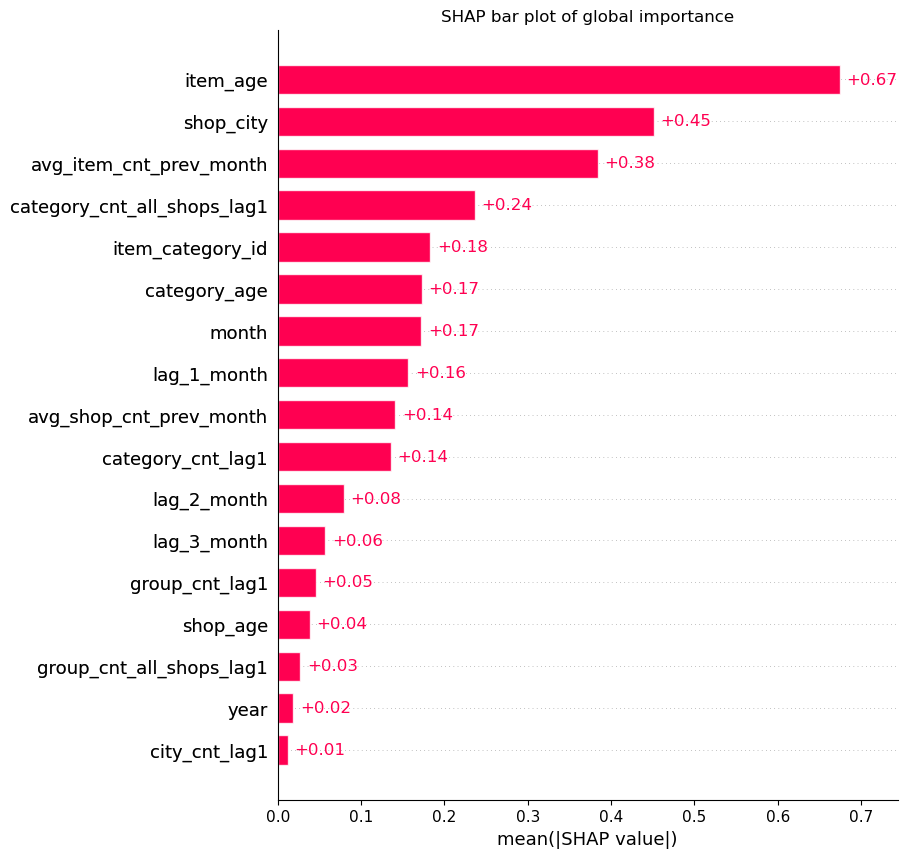

In [135]:
# Show global importance of features
plt.title("SHAP bar plot of global importance")
shap.plots.bar(shap_values, max_display=25)

Less important features in the model include `city_cat_lag_1`, `group_cnt_all_shops_lag1`, and `year`, as they have the lowest mean absolute SHAP values and minimal impact on predictions. As we have seen before, theese features demontrate high correlation.

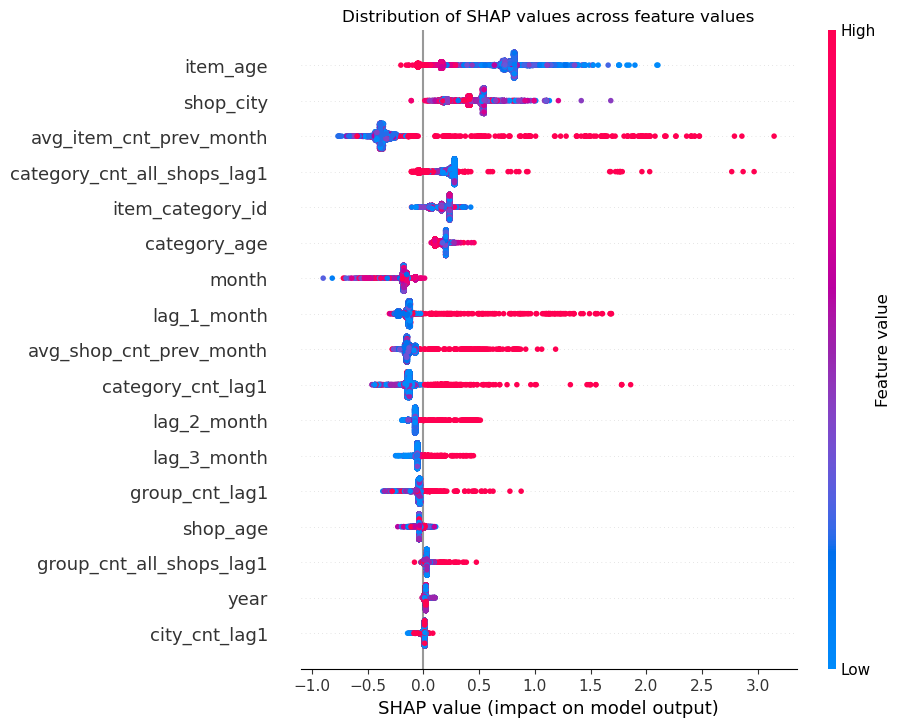

In [137]:
# Show beeswarm plot
plt.title("Distribution of SHAP values across feature values")
shap.plots.beeswarm(shap_values, max_display=25)

In [138]:
# Show a heatmap too long 
# shap.plots.heatmap(shap_values)
# plt.title("SHAP values across samples and features")

SHAP Dependence plot for 'lag_1_month'


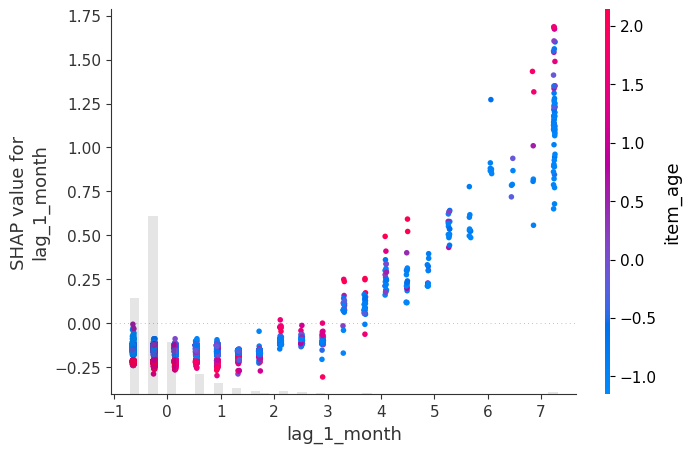

SHAP Dependence plot for 'lag_2_month'


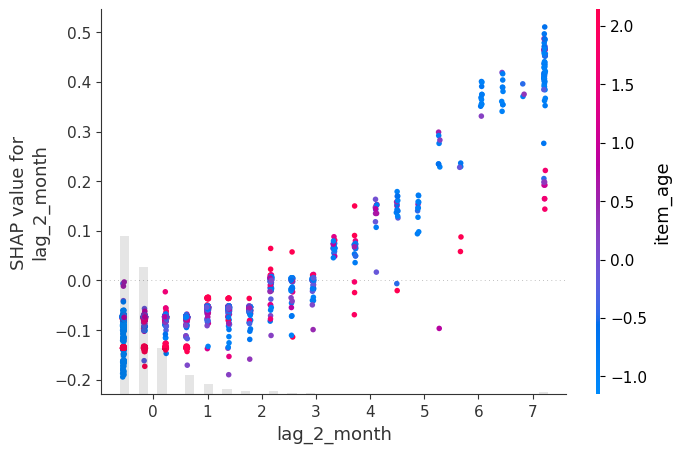

SHAP Dependence plot for 'lag_3_month'


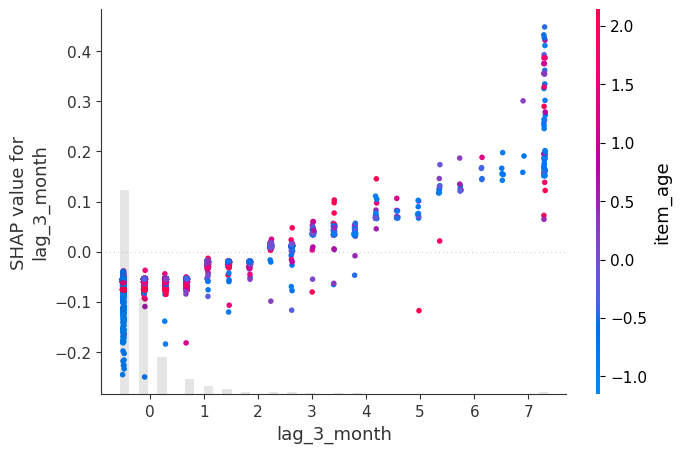

SHAP Dependence plot for 'avg_item_cnt_prev_month'


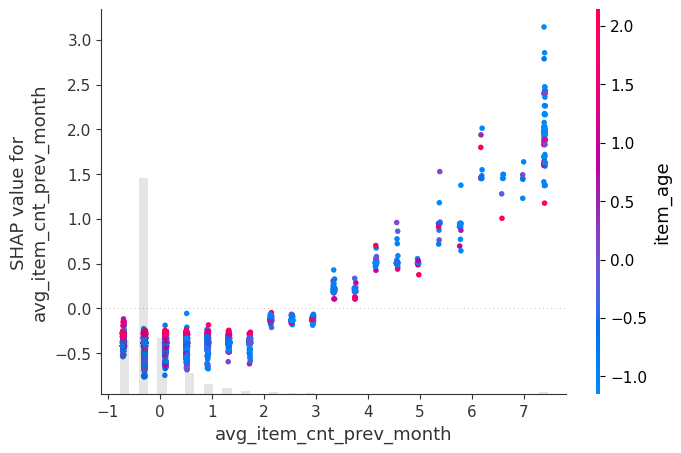

SHAP Dependence plot for 'avg_shop_cnt_prev_month'


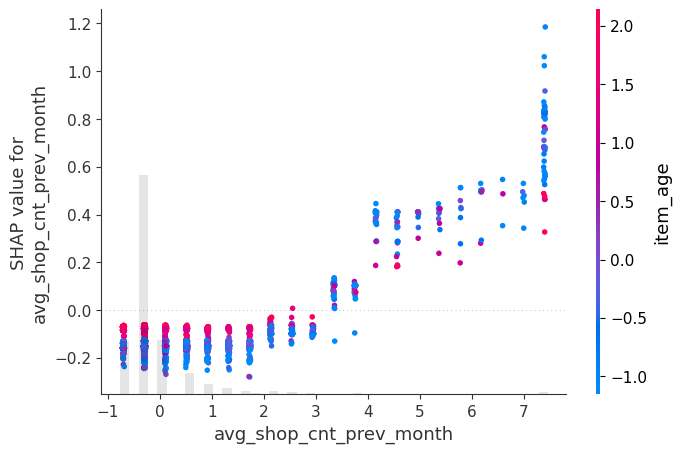

SHAP Dependence plot for 'month'


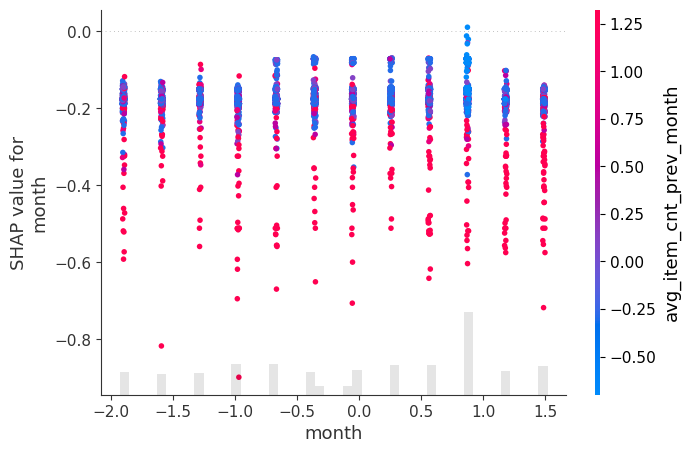

SHAP Dependence plot for 'year'


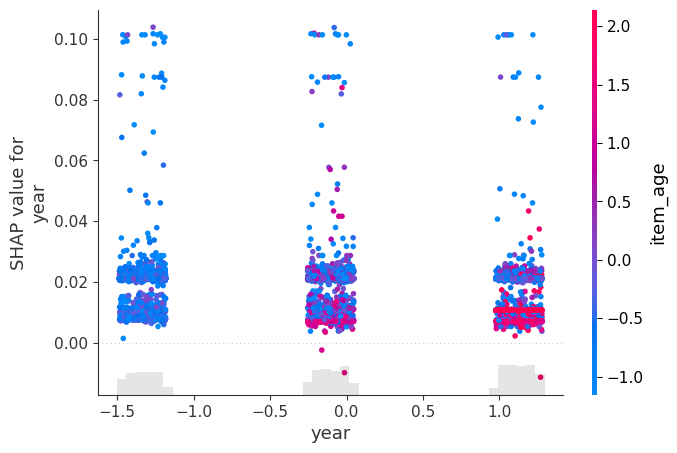

SHAP Dependence plot for 'item_age'


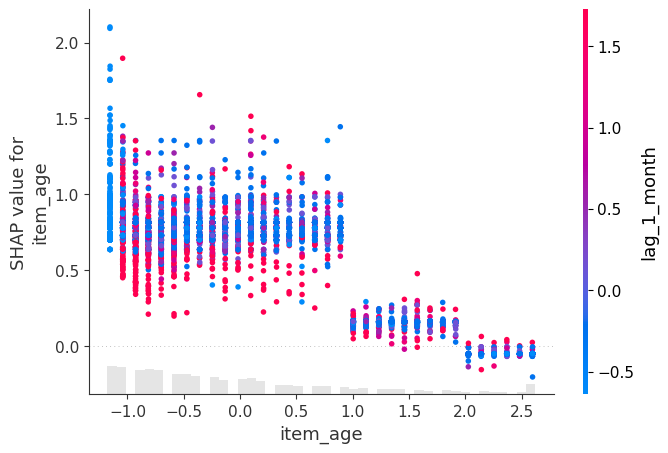

SHAP Dependence plot for 'shop_age'


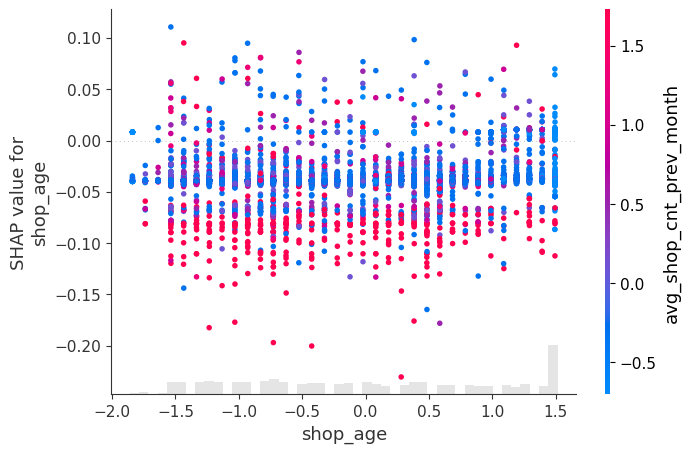

SHAP Dependence plot for 'category_age'


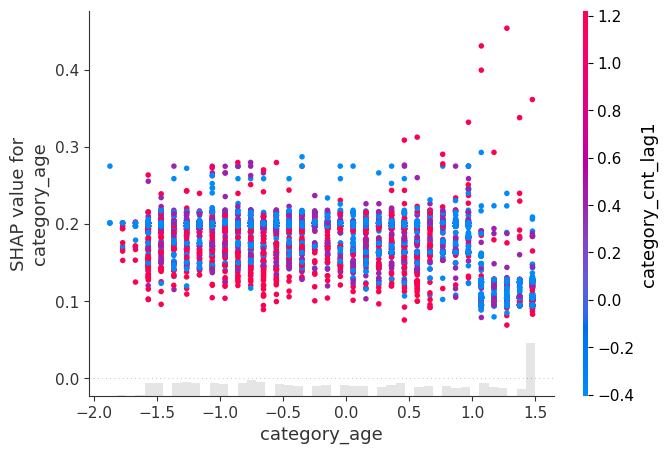

SHAP Dependence plot for 'item_category_id'


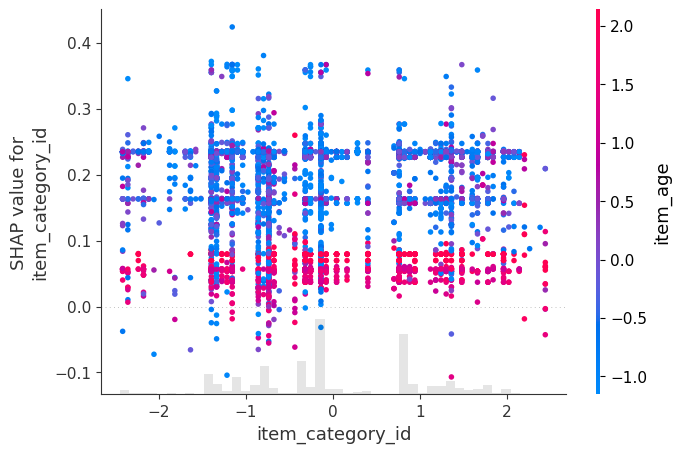

SHAP Dependence plot for 'shop_city'


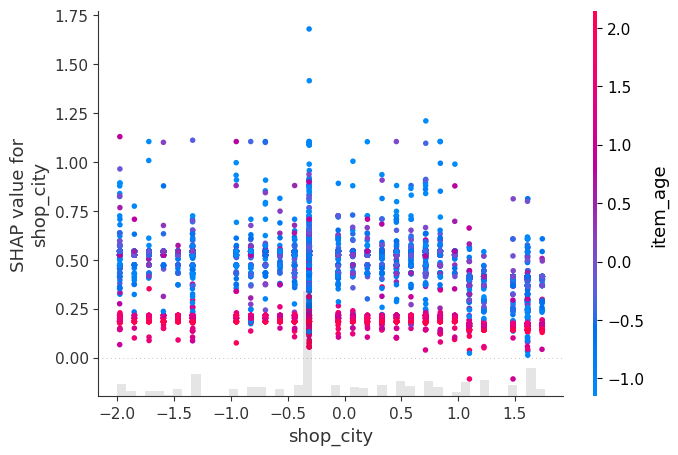

SHAP Dependence plot for 'category_cnt_lag1'


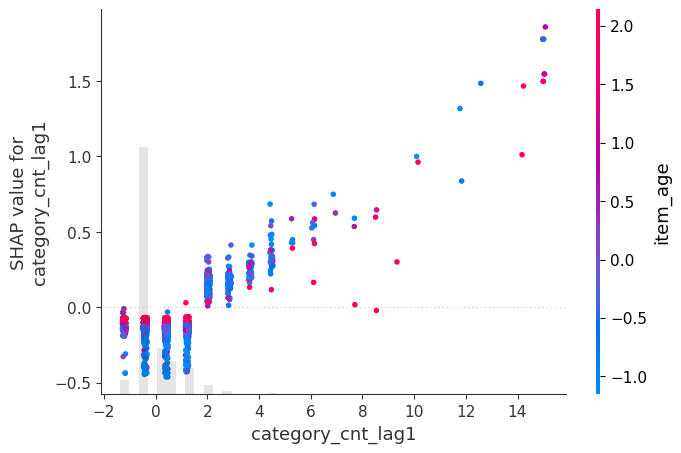

SHAP Dependence plot for 'category_cnt_all_shops_lag1'


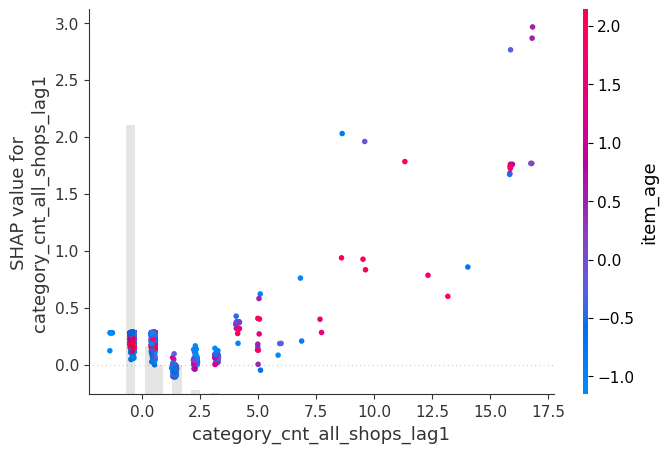

SHAP Dependence plot for 'group_cnt_lag1'


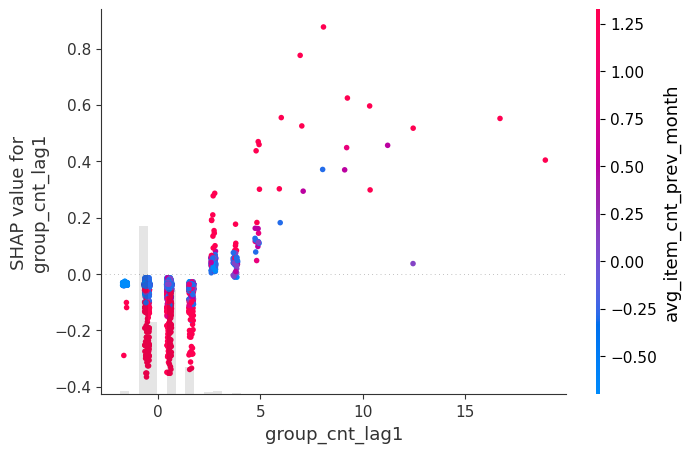

SHAP Dependence plot for 'group_cnt_all_shops_lag1'


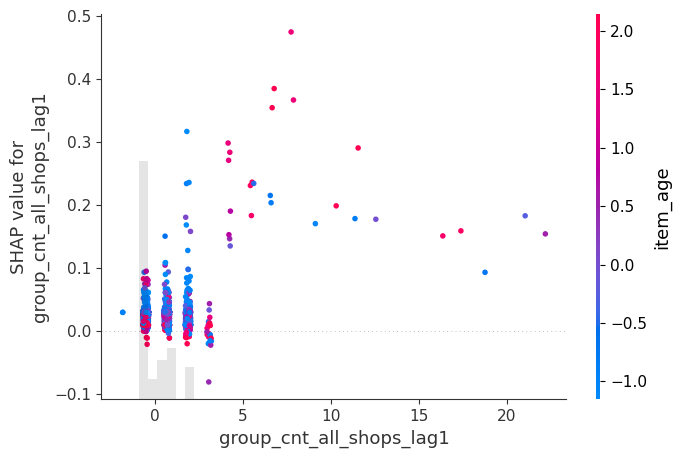

SHAP Dependence plot for 'city_cnt_lag1'


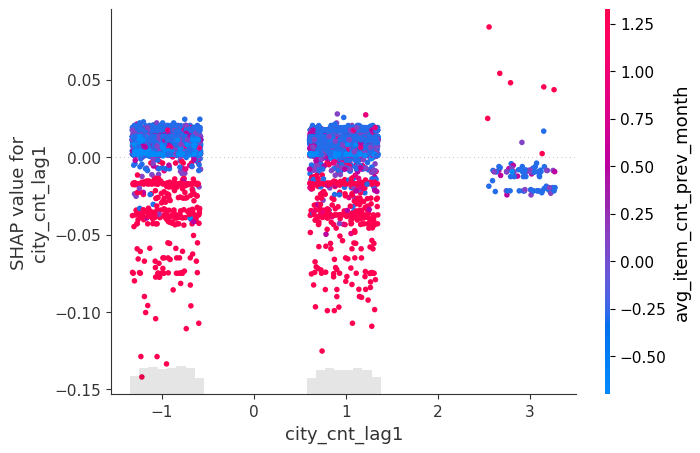

In [139]:
# Show dependence plot for all features
for feature_name in x.columns:
    print(f"SHAP Dependence plot for '{feature_name}'")
    shap.plots.scatter(shap_values[:, feature_name], color=shap_values)

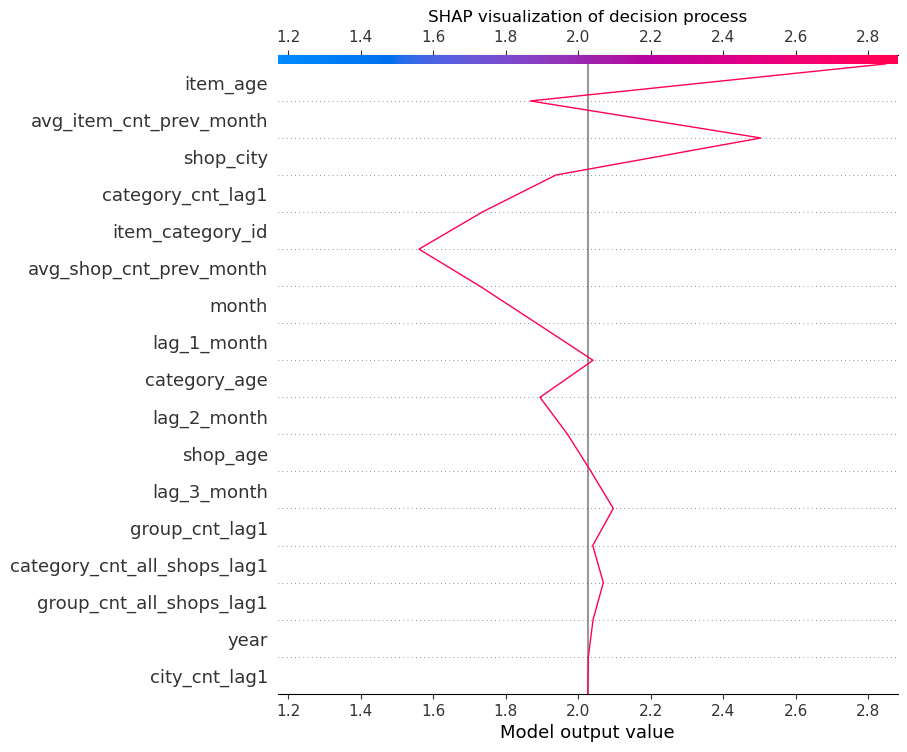

In [140]:
# Show decision plot with title
plt.title("SHAP visualization of decision process")

# Extract SHAP values and base value for one instance
instance_index = 0
shap_array = shap_values.values[instance_index]
base_value = shap_values.base_values[instance_index]
feature_names = x_sample.columns.tolist()  # or x.columns if using full data

# Plot decision path with feature names
shap.plots.decision(
    base_value=base_value,
    shap_values=shap_array,
    feature_names=feature_names
)

## Validator class

In [142]:
class TimeSeriesValidator:
    def __init__(self, n_splits=4, regr_error=None):
        # Initialize number of splits and error metric
        self.n_splits = n_splits
        self.regr_error = regr_error or self._rmse
        self.fold_metrics = []  # Stores RMSE per fold
        self.error_log = pd.DataFrame()  # Stores detailed error records

    @staticmethod
    def _rmse(y_true, y_pred):
        # Default error metric: root mean squared error
        return sqrt(mean_squared_error(y_true, y_pred))

    def validate(self, model, x, y):
        # Perform time series cross-validation
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        error_records = []

        for fold, (train_idx, val_idx) in enumerate(tscv.split(x)):
            # Split features and targets
            x_train, x_val = x.iloc[train_idx], x.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]  # NumPy slicing

            # Train model and predict
            model.fit(x_train, y_train)
            y_pred = model.predict(x_val)

            # Compute fold error and store
            fold_rmse = self.regr_error(y_val, y_pred)
            self.fold_metrics.append(fold_rmse)

            # Log prediction errors and target dynamics
            fold_df = pd.DataFrame({
                'timestamp': x_val.index,
                'fold': fold,
                'y_true': y_val,
                'y_pred': y_pred,
                'error': np.abs(y_val - y_pred),
                'target_magnitude': np.abs(y_val),
                'target_dynamic': np.abs(np.gradient(y_val))
            })
            error_records.append(fold_df)

        # Combine all fold logs
        self.error_log = pd.concat(error_records).reset_index(drop=True)
        return np.array(self.fold_metrics)


## Error analysis

In [144]:
class ModelErrorAnalyzer:
    def __init__(self, error_log: pd.DataFrame):
        # Store a copy of the error log for analysis
        self.df = error_log.copy()

    def plot_error_vs_target_magnitude(self):
        # Visualize how error scales with target magnitude
        sns.scatterplot(data=self.df, x='target_magnitude', y='error', alpha=0.5)

    def plot_error_vs_target_dynamic(self):
        # Show error vs target change rate (e.g. volatility)
        sns.scatterplot(data=self.df, x='target_dynamic', y='error', alpha=0.5)

    def report_top_errors(self, top_n=10):
        # Print top-N samples with highest prediction error
        top = self.df.sort_values(by='error', ascending=False).head(top_n)
        print(top[['timestamp', 'y_true', 'y_pred', 'error']])

    def describe_error_distribution(self):
        # Plot histogram and print descriptive stats of error
        sns.histplot(self.df['error'], bins=50, kde=True)
        print(self.df['error'].describe())

    def correlate_error_with_features(self, exclude_cols=None):
        # Compute and plot correlation between error and numeric features
        exclude = set(exclude_cols or ['timestamp', 'y_true', 'y_pred', 'error'])
        feature_cols = [c for c in self.df.select_dtypes('number') if c not in exclude]
        correlations = self.df[feature_cols + ['error']].corr()['error'].drop('error')
        sns.barplot(x=correlations.index, y=correlations.values)

    def flag_systematic_bias(self, feature='target_magnitude'):
        # Fit linear model to detect bias between error and a feature
        X = self.df[[feature]].values
        y = self.df['error'].values
        model = LinearRegression().fit(X, y)
        r2 = r2_score(y, model.predict(X))
        print(f"R² = {r2:.3f}. {'Bias detected' if r2 > 0.2 else 'No strong bias'}")

In [145]:
validator = TimeSeriesValidator()
validator.validate(model, x, y)

array([1.81841996, 1.6437703 , 1.6129933 , 1.30638957])

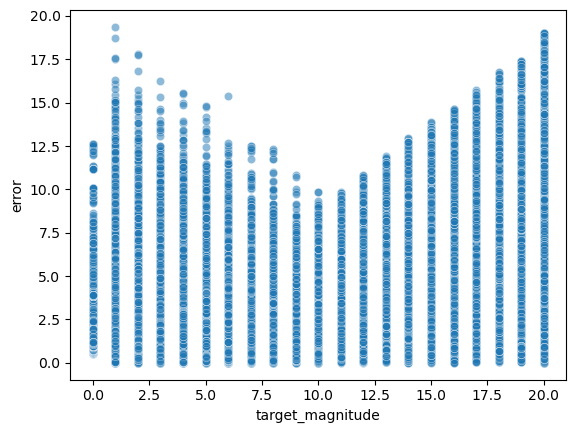

In [146]:
error_analyser = ModelErrorAnalyzer(validator.error_log)
error_analyser.plot_error_vs_target_magnitude()

The model performs most reliably within a mid-range of target values. Errors tend to increase at both low and high values of terget feature.

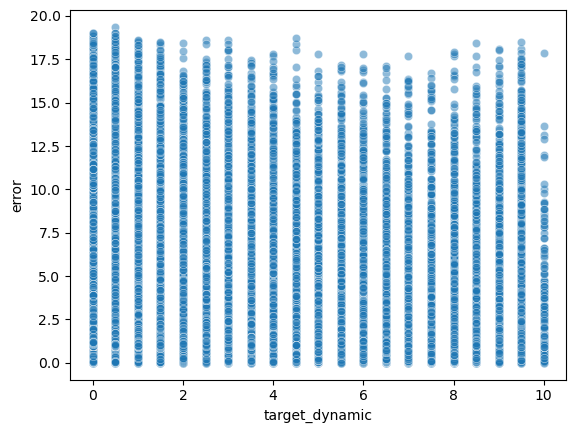

In [148]:
error_analyser.plot_error_vs_target_dynamic()

The scatter plot shows no clear dependency, suggesting that the model's prediction error is not significantly influenced by the rate of change or volatility of the target variable. This indicates that the model maintains consistent performance across varying levels of target dynamics, and does not exhibit systematic bias toward stable or fluctuating patterns.

In [150]:
error_analyser.report_top_errors()

         timestamp  y_true     y_pred      error
435246      707912     1.0  20.372959  19.372959
1002769    1275435    20.0   0.975367  19.024633
1002870    1275536    20.0   0.975367  19.024633
1001255    1273921    20.0   0.982913  19.017087
1003957    1276623    20.0   0.986518  19.013482
358858      631524    20.0   1.134144  18.865856
419205      691871    20.0   1.151254  18.848746
1014375    1287041    20.0   1.181410  18.818590
248240      520906    20.0   1.198787  18.801213
78807       351473    20.0   1.253015  18.746985


The model shows the highest errors when the target feature reaches a value of 20.

In [185]:
# The anomaly with the highest error

row_index = 435246
target_row = x.iloc[row_index]

# Вычисляем статистики по признакам
feature_max = x.max()
feature_min = x.min()
feature_mean = x.mean()

# Собираем таблицу отклонений
deviation_table = pd.DataFrame({
    'Feature Value': target_row,
    'From Mean': target_row - feature_mean,
    'From Max': target_row - feature_max,
    'From Min': target_row - feature_min
})

# Добавим абсолютные отклонения, если нужно
deviation_table['Abs From Mean'] = (target_row - feature_mean).abs()
deviation_table['Abs From Max'] = (target_row - feature_max).abs()
deviation_table['Abs From Min'] = (target_row - feature_min).abs()

# Сортировка по наибольшему отклонению от среднего
deviation_table = deviation_table.sort_values(by='Abs From Mean', ascending=False)

# Вывод
print(deviation_table.round(3))


                             Feature Value  From Mean  From Max  From Min  \
month                               -1.901     -1.901    -3.392     0.000   
shop_city                            1.611      1.611    -0.128     3.590   
city_cnt_lag1                        0.978      0.978    -1.926     3.853   
item_category_id                     0.882      0.882    -1.559     3.417   
shop_age                            -0.829     -0.829    -2.323     1.010   
category_age                        -0.656     -0.656    -2.134     1.220   
group_cnt_lag1                      -0.547     -0.547   -20.519     1.080   
group_cnt_all_shops_lag1            -0.537     -0.537   -22.807     1.200   
category_cnt_all_shops_lag1         -0.432     -0.432   -17.251     0.908   
category_cnt_lag1                   -0.405     -0.405   -15.438     0.813   
avg_shop_cnt_prev_month             -0.298     -0.298    -7.698     0.405   
avg_item_cnt_prev_month             -0.296     -0.296    -7.694     0.405   

The feature values of observation 435246 differ noticeably from the average, minimum, and maximum values in the dataset. Some features are much higher or lower than usual, which means this observation may be unusual or special in some way. These differences can help detect outliers or better understand how this case stands out compared to others.

count    1.090656e+06
mean     9.129806e-01
std      1.321259e+00
min      1.192093e-07
25%      2.103061e-01
50%      5.721087e-01
75%      1.069939e+00
max      1.937296e+01
Name: error, dtype: float64


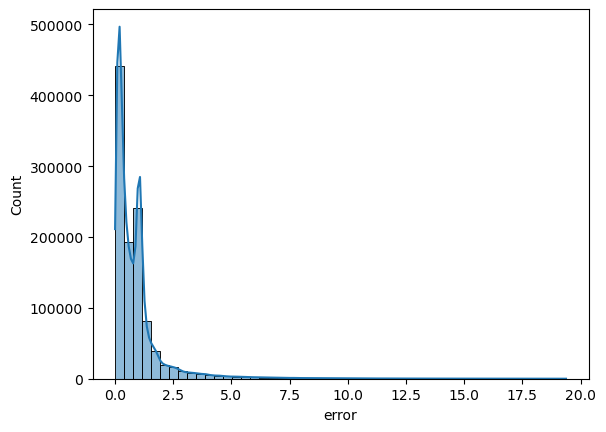

In [152]:
error_analyser.describe_error_distribution()

The model performs reliably, as errors are concentrated near zero.

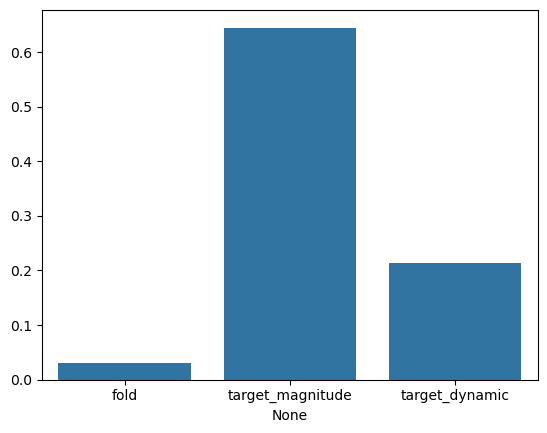

In [154]:
error_analyser.correlate_error_with_features()

In [155]:
error_analyser.flag_systematic_bias()

R² = 0.416. Bias detected


Error is correlated with target magnitude the most. It is higher for small and high values of target feature.